# Trabajo Práctico N°8 del TPS: Modelos de Lenguaje y Sistema de Recomendación



Este trabajo práctico se divide en dos partes. En la primera se explora el modelo de lenguaje FastText: se utilizan sus representaciones vectoriales pre-entrenadas para implementar analogías semánticas entre países y capitales, y se visualizan dichas representaciones mediante PCA. En la segunda se diseña un sistema de recomendación de materias de FIUBA basado en filtrado colaborativo, entrenado por gradiente descendente.

Se empieza por cargar e importar las librerías que se utilizarán a lo largo de este trabajo práctico.

In [1]:
import importlib, subprocess, sys

if importlib.util.find_spec("fasttext") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "fasttext-wheel"])

import os, gzip, shutil, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fasttext
from sklearn.decomposition import PCA

## 1. Modelo de Lenguaje


En esta sección se explora la capacidad semántica de un modelo de lenguaje pre-entrenado. La idea central es que, al entrenar una red neuronal para predecir palabras en contexto, las palabras quedan representadas como vectores en un espacio de alta dimensión donde la proximidad geométrica refleja similaridad semántica. Esto permite operar sobre significados mediante aritmética vectorial.

Se utilizan estas representaciones para resolver analogías del tipo *"A es a B como C es a ..."* y se visualiza la estructura del espacio mediante reducción de dimensionalidad con PCA.

### Contexto teórico

#### El problema de cómo representar palabras

Las redes neuronales trabajan con números. Una palabra como "king" no es un número, entonces hay que convertirla. Una solución simple es utilizar un one-hot vector (visto en TPs anteriores): si el vocabulario tiene $K$ palabras, "king" es un vector de $K$ dimensiones con un 1 en su posición y ceros en el resto. El problema es que si $K = 1.000.000$, cada palabra ocupa un vector de un millón de dimensiones para guardar básicamente un índice. Además, no captura ninguna relación semántica: "king" y "queen" son tan distintos como "king" y "banana".

#### Word2Vec: aprender representaciones del contexto

Word2Vec resuelve esto entrenando una red neuronal para predecir palabras vecinas. La observación clave es que palabras con significados similares aparecen en contextos similares: "king" y "queen" aparecen frecuentemente cerca de "throne", "crown", "royal". Esa regularidad estadística es lo que el modelo captura.

La arquitectura es simple: una red de una sola capa oculta con una matriz de pesos $W \in \mathbb{R}^{K \times 300}$. Cada fila de $W$ es el **embedding** de una palabra, un vector de 300 números que la describe. Al principio esos valores son aleatorios. El entrenamiento los va ajustando.

La tarea es: dada una palabra central, predecir sus vecinas dentro de una ventana de $\pm 2$ posiciones. Para cada par (central, vecina), la probabilidad predicha es:

$$P(\text{vecina} \mid \text{central}) = \sigma\!\left(\vec{v}_{\text{central}} \cdot \vec{v}_{\text{vecina}}\right)$$

donde $\sigma(x) = \frac{1}{1+e^{-x}}$ es la sigmoide, que convierte el producto escalar (qué tan alineados están los vectores) en una probabilidad entre 0 y 1. El ajuste que recibe cada vector en cada paso es:

$$\Delta \vec{v}_{\text{central}} = \alpha \cdot \underbrace{\bigl(1 - \sigma(\vec{v}_{\text{central}} \cdot \vec{v}_{\text{vecina}})\bigr)}_{\text{proporcional al error}} \cdot \underbrace{\vec{v}_{\text{vecina}}}_{\text{dirección del jalón}}$$

El jalón es proporcional al error actual: si los vectores ya están alineados, $\sigma \approx 1$ y el ajuste es casi nulo. Si están opuestos, $\sigma \approx 0$ y el ajuste es máximo. Es un sistema de retroalimentación: se corrige fuertemente cuando se está lejos y suave cuando se está cerca.

**Ejemplo concreto.** Se consideran dos oraciones del corpus:

> *"The king wore the **crown**"*  
> *"The **queen** wore the crown"*

Con ventana de $\pm 2$, la primera oración genera entre otros los pares *(king, crown)* y *(crown, king)*. Esto produce un jalón: $\vec{v}_{\text{king}}$ se mueve en dirección a $\vec{v}_{\text{crown}}$, y viceversa. La segunda oración genera *(queen, crown)* y *(crown, queen)*: $\vec{v}_{\text{queen}}$ también se acerca a $\vec{v}_{\text{crown}}$.

Ninguna oración generó el par *(king, queen)* directamente. Sin embargo, ambas palabras recibieron jalones hacia el mismo punto: *crown*. Como convergieron hacia la misma región, terminan cerca entre sí como efecto secundario. Ese mecanismo, repetido millones de veces con miles de palabras compartidas (throne, royal, realm...), es lo que hace que king y queen queden cerca en el espacio.

La palabra "the", en cambio, aparece en absolutamente todas las oraciones. Sus jalones vienen de todas las direcciones y se cancelan entre sí, dejando su vector en el centro del espacio, donde está cerca de todo y de nada. Por eso las *stop words* no aportan información discriminativa.

Tras millones de oraciones, las palabras que comparten contexto terminan con vectores similares, y las que aparecen en contextos distintos terminan en regiones distintas del espacio.

#### Lo que emerge: geometría semántica

El resultado sorprendente es que las relaciones semánticas se vuelven operaciones vectoriales. El ejemplo clásico:

$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

"King" y "queen" comparten vecinas de realeza (throne, crown, royal) pero difieren en vecinas de género (he/she, prince/princess). El modelo aprendió una dirección en $\mathbb{R}^{300}$ que separa géneros y otra que captura realeza. La resta cancela una y preserva la otra sin que nadie se lo haya enseñado explícitamente (es impresionante).

La métrica utilizada para medir proximidad entre vectores es la **similitud coseno**, que mide el ángulo entre dos vectores independientemente de su magnitud:

$$\text{sim}(\vec{u}, \vec{v}) = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \, \|\vec{v}\|}$$

El resultado está entre $[-1, 1]$: vale 1 si los vectores apuntan en la misma dirección, 0 si son perpendiculares, y $-1$ si son opuestos. Se prefiere sobre la distancia euclídea porque los embeddings de FastText no están normalizados, es decir, dos palabras frecuentes tendrán vectores de mayor norma que palabras raras, y la distancia euclídea confundiría esa diferencia de escala con diferencia semántica. El coseno la elimina al normalizar.

#### Limitación de Word2Vec → FastText

Word2Vec trata cada palabra como una unidad atómica. Si una palabra no apareció en el entrenamiento, no tiene embedding. Tampoco aprovecha que "run", "running" y "runner" comparten estructura morfológica.

**FastText** resuelve esto descomponiendo cada palabra en **n-gramas de caracteres**. Por ejemplo, "playing" se divide en `<pl`, `pla`, `lay`, `ayi`, `yin`, `ing`, `ng>`, y su embedding es la suma de los vectores de esos fragmentos:

$$\vec{v}_{\text{playing}} = \sum_{g \in \mathcal{G}(\text{playing})} \vec{z}_g$$

Esto tiene dos consecuencias: las palabras nuevas se construyen desde sus partes, y las palabras con raíces comunes ("run", "running", "runner") comparten n-gramas y por lo tanto reciben jalones en las mismas direcciones durante el entrenamiento, de esta manera, su similitud morfológica se refleja en el espacio vectorial. Todo lo demás (tarea, gradiente, convergencia) es idéntico a Word2Vec.

El modelo utilizado en este trabajo (`cc.en.300.bin`) fue entrenado por Facebook sobre 600 mil millones de tokens del Common Crawl en inglés. Internamente almacena dos tablas de embeddings de 300 dimensiones: una con ~2 millones de vectores de palabras y otra con ~2 millones de vectores de n-gramas. Al consultar una palabra, FastText suma ambas contribuciones; para palabras fuera del vocabulario, usa únicamente los n-gramas.



### (a) Carga del modelo FastText

In [2]:
MODEL_GZ  = "cc.en.300.bin.gz"
MODEL_BIN = "cc.en.300.bin"
URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz"

if not os.path.exists(MODEL_BIN):
    if not os.path.exists(MODEL_GZ):
        print("Descargando modelo (~4.2 GB)...")
        urllib.request.urlretrieve(URL, MODEL_GZ)
        print("Descarga completa.")
    print("Descomprimiendo...")
    with gzip.open(MODEL_GZ, "rb") as f_in, open(MODEL_BIN, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    print("Listo.")
else:
    print(f"Modelo ya disponible: {MODEL_BIN}")

model = fasttext.load_model(MODEL_BIN)
print("Modelo cargado.")

Descargando modelo (~4.2 GB)...
Descarga completa.
Descomprimiendo...
Listo.
Modelo cargado.


#### Exploración del modelo

Antes de trabajar con las analogías, se analiza el espacio de embeddings cargado para ganar intuición sobre su estructura. En particular, se verifica que los vectores tienen la forma esperada (300 dimensiones con valores de magnitud moderada), se contrasta la similitud coseno entre pares de palabras con distintas relaciones semánticas (desde palabras co-ocurrentes hasta palabras sin relación) y se comprueba empíricamente que la aritmética vectorial captura relaciones de género, confirmando el comportamiento teórico descrito en la sección anterior.

In [3]:
def cos_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# 1. Dimensión y rango de valores de un embedding
v_king = model.get_word_vector("king")
print(f"Dimensión del embedding: {v_king.shape}")
print(f"Rango de valores: [{v_king.min():.3f}, {v_king.max():.3f}]")
print(f"Norma: {np.linalg.norm(v_king):.3f}")
print()

# 2. Similitud coseno entre pares con distintas relaciones semánticas
pares = [
    ("king",   "queen",   "mismo tema, género distinto"),
    ("king",   "throne",  "co-ocurrentes directos"),
    ("king",   "France",  "sin relación"),
    ("king",   "banana",  "sin relación"),
    ("Paris",  "London",  "ambas capitales europeas"),
    ("run",    "running", "misma raíz (FastText ventaja)"),
]
print("Similitudes coseno:")
print(f"{'Par':<30} {'Similitud':>10}  Relación")
print("-" * 65)
for w1, w2, desc in pares:
    s = cos_sim(model.get_word_vector(w1), model.get_word_vector(w2))
    print(f"{w1+' ↔ '+w2:<30} {s:>10.4f}  {desc}")
print()

# 3. Verificación de la aritmética vectorial: king - man + woman ≈ ?
query = model.get_word_vector("king") - model.get_word_vector("man") + model.get_word_vector("woman")
candidatos = ["queen", "king", "woman", "man", "princess", "monarch", "throne"]
print("king - man + woman → similitudes con candidatos:")
for c in candidatos:
    s = cos_sim(query, model.get_word_vector(c))
    print(f"  {c:<12} {s:.4f}")

Dimensión del embedding: (300,)
Rango de valores: [-0.275, 0.227]
Norma: 1.558

Similitudes coseno:
Par                             Similitud  Relación
-----------------------------------------------------------------
king ↔ queen                       0.7069  mismo tema, género distinto
king ↔ throne                      0.5728  co-ocurrentes directos
king ↔ France                      0.1797  sin relación
king ↔ banana                      0.1493  sin relación
Paris ↔ London                     0.5923  ambas capitales europeas
run ↔ running                      0.7398  misma raíz (FastText ventaja)

king - man + woman → similitudes con candidatos:
  queen        0.6543
  king         0.7287
  woman        0.0095
  man          -0.2743
  princess     0.4449
  monarch      0.4914
  throne       0.4458


**Análisis de resultados.** Los embeddings tienen dimensión 300 y norma ~1.558, lo que confirma que los vectores no están normalizados: la escala varía por palabra y no aporta información semántica. De ahí la necesidad del coseno.

La similitud coseno puede interpretarse como un índice de compatibilidad semántica: cuanto más alto, mayor la probabilidad de que las dos palabras compartan contexto en el corpus, es decir, de que el modelo las haya "visto juntas" con frecuencia. Los valores observados siguen el orden esperado:

| Par | Similitud | Interpretación |
|-----|-----------|----------------|
| run ↔ running | 0.7398 | morfológicamente idénticas (FastText) |
| king ↔ queen | 0.7069 | mismo dominio semántico, género distinto |
| Paris ↔ London | 0.5923 | ambas capitales europeas |
| king ↔ throne | 0.5728 | co-ocurrentes directos |
| king ↔ France | 0.1797 | sin relación directa |
| king ↔ banana | 0.1493 | sin relación |

Para la aritmética vectorial, el vector query $\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}}$ es aún más similar a king (0.7287) que a queen (0.6543), dado que el punto de partida es king y la corrección de género es una perturbación pequeña en $\mathbb{R}^{300}$. Excluyendo las palabras de entrada del ranking (como hace la función `analogy`) queen resulta el candidato más próximo, lo que valida empíricamente el comportamiento teórico.

### (b) Analogías

Lo que se hace en esta sección es evaluarlo: se le plantean preguntas con respuesta conocida (¿la capital de England es London?) y se verifica si sus vectores capturan correctamente esa relación geográfica.

El fundamento es que si el entrenamiento fue exitoso, existe una dirección consistente en $\mathbb{R}^{300}$ que codifica la relación "capital de". Entonces para cualquier país $C$, la operación $\vec{B} - \vec{A} + \vec{C}$ (donde $A$ es un país de referencia y $B$ su capital) desplaza el vector de $C$ en esa dirección, produciendo un vector próximo a la capital de $C$.

La búsqueda se restringe al vocabulario de `country-list.csv` (países y capitales) para garantizar que la respuesta sea un nombre geográfico del conjunto de interés.

A continuación, se carga el archivo `country-list.csv` y se construye la lista `words` con todos los países y capitales sin repetidos. A partir de ella se pre-computa la matriz `word_vectors` $\in \mathbb{R}^{N \times 300}$, donde cada fila es el embedding de la palabra correspondiente. Hacerlo una sola vez evita llamar al modelo repetidamente durante cada consulta; la búsqueda del vecino más cercano se reduce entonces a un único producto matricial.

In [4]:
# Cargar país-capital y construir base de datos de vectores

COUNTRY_CSV = "country-list.csv"
COUNTRY_URL = "https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/country-list.csv"

if not os.path.exists(COUNTRY_CSV):
    urllib.request.urlretrieve(COUNTRY_URL, COUNTRY_CSV)

df = pd.read_csv(COUNTRY_CSV)

words = pd.concat([df.iloc[:, 0], df.iloc[:, 1]]).unique().tolist()
word_vectors = np.array([model.get_word_vector(w) for w in words])

Se implementa la función `cosine_similarity(v, M)`, que calcula la similitud coseno entre el vector consulta $\vec{v}$ y cada fila $\vec{m}_i$ de la matriz $M$. En lugar de iterar sobre los $N$ vectores en Python, se vectoriza la operación:

1. Se normaliza $\vec{v}$ → $\hat{v} = \vec{v}/\|\vec{v}\|$
2. Se normaliza cada fila de $M$ → $\hat{M}$
3. Se calcula el producto $\hat{M} \cdot \hat{v}$, que entrega directamente el vector $[\hat{m}_1 \cdot \hat{v},\ \dots,\ \hat{m}_N \cdot \hat{v}]$

El paso 3 es un único producto matriz-vector ejecutado por numpy en C, sin loop de Python, por lo que es más rápido que calcular cada similitud por separado.

La función `analogy(A, B, C)` construye el vector consulta $\vec{q} = \vec{B} - \vec{A} + \vec{C}$, lo compara contra toda la base de datos usando `cosine_similarity`, excluye las palabras de entrada del ranking y devuelve los 3 candidatos más cercanos. La evaluación se realiza en dos etapas: primero con tres pares de referencia europeos sobre 5 países aleatorios, luego con un par por continente sobre los mismos países, para analizar si la elección del par de referencia influye en el resultado.

In [16]:
refs = [("France", "Paris"), ("Germany", "Berlin"), ("Spain", "Madrid")]
ref_countries = {r[0] for r in refs}

country_to_capital = dict(zip(df.iloc[:, 0], df.iloc[:, 1]))

rng = np.random.default_rng(49)
candidates = [c for c in df.iloc[:, 0] if c not in ref_countries]
test_countries = list(rng.choice(candidates, size=5, replace=False))

total_correct = [0] * len(refs)

for country in test_countries:
    correct_cap = country_to_capital[country]
    top3s = []
    marks = []

    for A, B in refs:
        results = analogy(A, B, country, top_k=3)
        top1 = results[0][0]
        top3s.append(results)
        marks.append("✓" if top1 == correct_cap else "✗")

    for i, m in enumerate(marks):
        total_correct[i] += int(m == "✓")

    n_correct = sum(m == "✓" for m in marks)
    print(f"▶ {country}  (capital: {correct_cap})  [{n_correct}/{len(refs)} referencias acertaron]")
    for (A, B), results, mark in zip(refs, top3s, marks):
        candidates_str = " | ".join(f"{w} ({s:.4f})" for w, s in results)
        print(f"   {A}/{B:<8}: {candidates_str}  {mark}")
    print()

print("─" * 60)
print("Resumen:")
for i, (A, B) in enumerate(refs):
    print(f"  {A}/{B}: {total_correct[i]}/5")

▶ Argentina  (capital: Buenos Aires)  [0/3 referencias acertaron]
   France/Paris   : Caracas (0.5904) | Madrid (0.5898) | Bogotá (0.5740)  ✗
   Germany/Berlin  : Montevideo (0.5995) | Havana (0.5726) | Caracas (0.5650)  ✗
   Spain/Madrid  : Caracas (0.4803) | Asunción (0.4797) | Montevideo (0.4779)  ✗

▶ Namibia  (capital: Windhoek)  [3/3 referencias acertaron]
   France/Paris   : Windhoek (0.7149) | Gaborone (0.6248) | Nairobi (0.6146)  ✓
   Germany/Berlin  : Windhoek (0.7363) | Botswana (0.6765) | Pretoria (0.6319)  ✓
   Spain/Madrid  : Windhoek (0.7046) | Gaborone (0.6150) | Lusaka (0.5744)  ✓

▶ Armenia  (capital: Yerevan)  [3/3 referencias acertaron]
   France/Paris   : Yerevan (0.7680) | Tbilisi (0.6497) | Stepanakert (0.6327)  ✓
   Germany/Berlin  : Yerevan (0.8014) | Tbilisi (0.6695) | Stepanakert (0.6431)  ✓
   Spain/Madrid  : Yerevan (0.7650) | Stepanakert (0.6744) | Tbilisi (0.5890)  ✓

▶ Sri Lanka  (capital: Sri Jayawardenapura Kotte)  [0/3 referencias acertaron]
   France

**Análisis de resultados.** La evaluación muestra 2/5 de precisión top-1 por cada par de referencia y 4/5 de consistencia. La lectura superficial sugiere un rendimiento mediocre, pero el análisis caso por caso revela que los fallos no son aleatorios: responden a mecanismos distintos que se pueden identificar directamente desde los valores de similitud coseno.

**Casos correctos: Namibia y Armenia.** Similitudes top-1 superiores a 0.70, con runners-up geográficamente coherentes (Gaborone, Tbilisi). La dirección "capital de" es estable y clara en esas regiones del espacio vectorial.

**Fallo por cobertura insuficiente de corpus: Sri Lanka.** Las similitudes top-1 caen al rango 0.36–0.46, prácticamente la mitad que los casos exitosos. La capital oficial (*Sri Jayawardenapura Kotte*) es raramente mencionada en texto en inglés, donde se usa *Colombo*. Dado que FastText construye embeddings a partir de co-ocurrencias estadísticas, una palabra sin presencia real en el corpus queda sin posición semántica significativa aunque su vector técnicamente existe (construido por n-gramas). Los candidatos devueltos (N'Djamena, South Ossetia) no guardan relación geográfica con Sri Lanka; el modelo está extrapolando sin señal. Las bajas similitudes son el indicador: el query vector aterrizó en una zona de baja densidad del espacio.

**Fallo por vecino geográfico dominante: Guam.** Las similitudes son moderadas-altas (0.58–0.75) y la capital correcta (*Hagåtña*) aparece en top-3 en los tres pares de referencia, pero en segundo lugar, sistemáticamente desplazada por Saipan (capital de las Islas Marianas del Norte, territorio adyacente). Guam y Saipan co-ocurren frecuentemente en el corpus en contextos como *"Pacific island territories"*; esa asociación estadística supera a la relación formal capital-país. El fallo es consistente porque el sesgo es estructural.

**Fallo por ambigüedad regional: Argentina.** Buenos Aires no aparece en ningún top-3. Los tres pares de referencia devuelven capitales sudamericanas distintas (Caracas, Montevideo, Bogotá), produciendo inconsistencia. Se infiere que los países de América del Sur forman un cluster semántico denso: comparten idioma, cobertura mediática similar y co-menciones frecuentes en el corpus. La dirección "capital de" existe pero queda ahogada por la similitud regional; pequeñas variaciones en el vector de referencia desplazan el resultado entre vecinos equivalentes. La inconsistencia confirma que la señal es débil, no ausente.

**Similitud top-1 como indicador de confianza.** Los resultados sugieren un patrón empírico: similitudes >0.70 corresponden a predicciones correctas; entre 0.50 y 0.70, fallo estructural consistente (el modelo elige un vecino equivocado con alta confianza); $<0.50$, ausencia de representación real en el corpus. Este umbral podría usarse en aplicaciones prácticas para decidir si aceptar o rechazar la predicción.

#### Evaluación con referencia por continente

La evaluación anterior usó exclusivamente pares de referencia europeos (France/Paris, Germany/Berlin, Spain/Madrid). Esto plantea una pregunta: ¿la dirección "capital de" es verdaderamente universal en el espacio vectorial, o es más fuerte cuando el par de referencia pertenece a la misma región geográfica que el país consultado? Para testear esto, se mantienen los mismos 5 países aleatorios (misma semilla) pero se reemplazan los 3 pares europeos por uno de cada continente: France/Paris (Europa), Brazil/Brasília (América), Kenya/Nairobi (África), Japan/Tokyo (Asia) y Australia/Canberra (Oceanía). Si la hipótesis regional es correcta, Brazil/Brasília debería acertar para Argentina donde France/Paris falló, y Australia/Canberra podría cambiar el resultado para Guam.

In [17]:
# Un par de referencia por continente — mismos 5 países de la evaluación anterior
refs_ext = [
    ("France",    "Paris",    "Europa"),
    ("Brazil",    "Brasília", "América"),
    ("Kenya",     "Nairobi",  "África"),
    ("Japan",     "Tokyo",    "Asia"),
    ("Australia", "Canberra", "Oceanía"),
]

print("Evaluación con pares de referencia por continente\n")
total_ext = [0] * len(refs_ext)

for country in test_countries:
    correct_cap = country_to_capital[country]
    top3s = []
    marks = []

    for A, B, _ in refs_ext:
        results = analogy(A, B, country, top_k=3)
        top1 = results[0][0]
        top3s.append(results)
        marks.append("✓" if top1 == correct_cap else "✗")

    for i, m in enumerate(marks):
        total_ext[i] += int(m == "✓")

    n_correct = sum(m == "✓" for m in marks)
    print(f"▶ {country}  (capital: {correct_cap})  [{n_correct}/{len(refs_ext)} referencias acertaron]")
    for (A, B, cont), results, mark in zip(refs_ext, top3s, marks):
        candidates_str = " | ".join(f"{w} ({s:.4f})" for w, s in results)
        print(f"   [{cont:<8}] {A}/{B:<12}: {candidates_str}  {mark}")
    print()

print("─" * 60)
print("Resumen:")
for i, (A, B, cont) in enumerate(refs_ext):
    print(f"  [{cont}] {A}/{B}: {total_ext[i]}/5")

Evaluación con pares de referencia por continente

▶ Argentina  (capital: Buenos Aires)  [0/5 referencias acertaron]
   [Europa  ] France/Paris       : Caracas (0.5904) | Madrid (0.5898) | Bogotá (0.5740)  ✗
   [América ] Brazil/Brasília    : Asunción (0.5588) | Bogotá (0.5114) | Montevideo (0.4787)  ✗
   [África  ] Kenya/Nairobi     : Montevideo (0.5345) | Madrid (0.5174) | Asunción (0.4953)  ✗
   [Asia    ] Japan/Tokyo       : Caracas (0.5881) | Bogotá (0.5698) | Madrid (0.5537)  ✗
   [Oceanía ] Australia/Canberra    : Montevideo (0.6120) | Uruguay (0.5933) | Asunción (0.5824)  ✗

▶ Namibia  (capital: Windhoek)  [5/5 referencias acertaron]
   [Europa  ] France/Paris       : Windhoek (0.7149) | Gaborone (0.6248) | Nairobi (0.6146)  ✓
   [América ] Brazil/Brasília    : Windhoek (0.7292) | Gaborone (0.6413) | Botswana (0.6239)  ✓
   [África  ] Kenya/Nairobi     : Windhoek (0.7248) | Gaborone (0.5746) | Pretoria (0.5576)  ✓
   [Asia    ] Japan/Tokyo       : Windhoek (0.7411) | Gaborone (

**Análisis comparativo.** La pregunta central era si el continente del par de referencia afecta el resultado. La respuesta es clara: **no, no lo afecta**. Para todos los casos que ya funcionaban (Namibia, Armenia) o que ya fallaban (Argentina, Guam), cambiar el par de referencia de Europa a América, África, Asia u Oceanía no modifica el resultado. Esto permite reformular y profundizar cada hipótesis anterior.

**Ambigüedad regional (Argentina): hipótesis confirmada y refinada.** En la evaluación anterior se especuló que los pares de referencia europeos no eran ideales para un cluster sudamericano. Los resultados refutan esa explicación: Brazil/Brasília (mismo continente,  geografía adyacente) tampoco encuentra Buenos Aires. La causa no está en el par de referencia sino en el destino: los países de América del Sur están tan comprimidos en el espacio vectorial que la operación $\vec{B} - \vec{A} + \vec{C}$ aterriza en la nube colectiva de capitales sudamericanas independientemente de dónde empiece. El resultado varía (Caracas, Asunción, Montevideo, Bogotá) porque la nube es densa y el punto de llegada exacto depende del sesgo de cada referencia, pero Buenos Aires nunca se distingue del resto. Es un problema del espacio vectorial de Argentina, no del par de referencia.

**Sesgo de vecino dominante (Guam): hipótesis confirmada y fortalecida.** Australia/Canberra (Oceanía) sigue dando Saipan como top-1 con similitud 0.76 (incluso mayor que la referencia europea). La asociación Guam-Saipan en el corpus es tan fuerte que domina el resultado desde cualquier punto de partida. No hay par de referencia que pueda compensarlo: una vez que el query vector apunta hacia esa región del Pacífico, el atractor más cercano es siempre Saipan. El mecanismo no es ambigüedad (el modelo no duda) sino sobrerepresentación de una relación geográfica incorrecta.

**Cobertura de corpus (Sri Lanka): hipótesis confirmada, con matiz importante.** Kenya/Nairobi es el único par que obtiene Sri Jayawardenapura Kotte como top-1 (0.40). Sin embargo, la capital correcta aparece en el top-3 de tres referencias: África (#1), América (#2, 0.41 vs 0.43 de N'Djamena) y Oceanía (#2, 0.48 vs 0.50 de N'Djamena). En estos últimos dos casos la diferencia con el top-1 es inferior a 0.02, esencialmente un empate dentro del margen de ruido. El modelo sí tiene alguna señal para esa capital: la encuentra, pero compite en igualdad de condiciones con N'Djamena (otra capital con cobertura limitada en el corpus en inglés). Lo que falla no es que el modelo ignora la capital sino que no tiene suficiente señal para distinguirla de otras ciudades igualmente infrecuentes. Europa y Asia no la muestran en ningún top-3, lo que sugiere que esas referencias apuntan a una zona del espacio más alejada.

**Conclusión general.** La operación de analogía $\vec{q} = \vec{B} - \vec{A} + \vec{C}$ toma la diferencia vectorial entre el par de referencia y la aplica desde el vector del país consultado. El resultado final es el punto del diccionario más cercano a $\vec{q}$. Cambiar el par de referencia cambia el punto de partida y la dirección del salto, pero el destino siempre cae en la misma región del espacio, cerca del país consultado. Lo que determina la respuesta no es la referencia sino la geometría de esa región:

- **Zona con atractor fuerte y correcto** (Armenia, Namibia): sin importar exactamente dónde caiga el query, el vecino más cercano es siempre el mismo. La respuesta es estable y correcta desde cualquier referencia.
- **Zona con atractor incorrecto dominante** (Guam): el query cae cerca de Guam pero Saipan tiene más masa semántica en el corpus que Hagåtña. El atractor equivocado gana siempre, independientemente de la referencia.
- **Zona densa sin atractor único** (Argentina): el query cae en el cluster sudamericano pero ninguna capital domina sobre las demás. El resultado fluctúa según el punto de partida exacto.
- **Zona de señal débil** (Sri Lanka): el query cae en una región de baja densidad donde la capital correcta y otras ciudades igualmente infrecuentes están a similitudes casi idénticas. El resultado es inestable y depende de detalles del salto.

En los cuatro casos, la elección del par de referencia es secundaria: no puede corregir una geometría desfavorable ni arruinar una favorable.

### (c) Representación gráfica (PCA 2D)

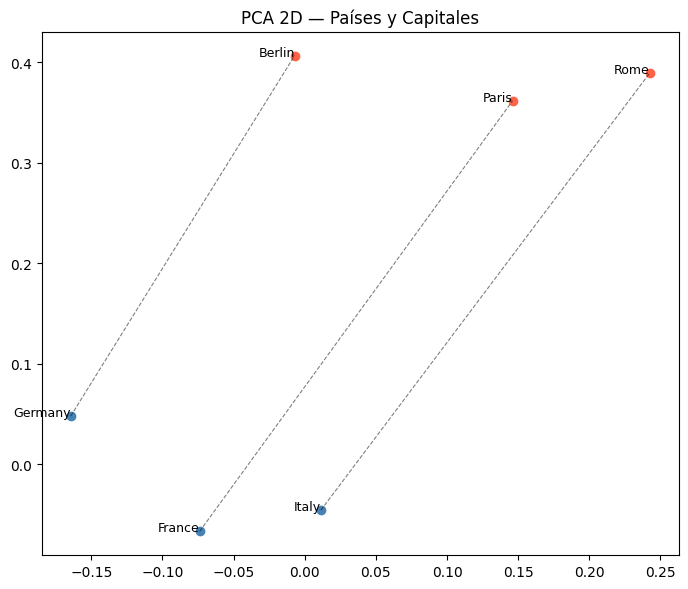

In [6]:
pca = PCA(n_components=2)
coords = pca.fit_transform(word_vectors)
word_to_idx = {w: i for i, w in enumerate(words)}

pairs = [("Italy", "Rome"), ("France", "Paris"), ("Germany", "Berlin")]

fig, ax = plt.subplots(figsize=(7, 6))
for country, capital in pairs:
    ci, cc = word_to_idx[country], word_to_idx[capital]
    ax.scatter(*coords[ci], color="steelblue")
    ax.scatter(*coords[cc], color="tomato")
    ax.annotate(country, coords[ci], fontsize=9, ha="right")
    ax.annotate(capital, coords[cc], fontsize=9, ha="right")
    ax.plot([coords[ci, 0], coords[cc, 0]], [coords[ci, 1], coords[cc, 1]],
            "k--", linewidth=0.8, alpha=0.5)

ax.set_title("PCA 2D — Países y Capitales")
plt.tight_layout()
plt.show()